In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from datetime import datetime

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/data-crunch-round-1/sample_submission.csv
/kaggle/input/data-crunch-round-1/train.csv
/kaggle/input/data-crunch-round-1/test.csv


In [3]:
periods = [354, 188, 177]

def to_date(year, month, day):
    return datetime(year=2018+year, month=month, day=day)

def from_date(date):
    return date.year-2018, date.month, date.day

def add_period(df):
    for p in periods:
        day_of_p = ((df.index - df.index.min()).days % p) + 1
        df[f'sin_day_of_{p}'] = np.sin(2 * np.pi * day_of_p / p)
        df[f'cos_day_of_{p}'] = np.cos(2 * np.pi * day_of_p / p)
    return df

def get_period_features():
    for p in periods:
        yield f'sin_day_of_{p}'
        yield f'cos_day_of_{p}'

In [6]:


df = pd.read_csv("/kaggle/input/data-crunch-round-1/train.csv")
target = ['Avg_Temperature', 'Radiation', 'Rain_Amount','Wind_Speed', 'Wind_Direction']
df['Avg_Temperature'] = df['Avg_Temperature'].apply(lambda x: x - 273.15 if x > 200 else x)
df['Date'] = df.apply(lambda row: datetime(year=2018+row['Year'], 
                                                     month=row['Month'], 
                                                     day=row['Day']), axis=1)
df = df.sort_values(by=['kingdom', 'Date'], ascending=[True, True])
df[target] = df[target].rolling(window=20, center=True).mean()
df = df.sort_values(by=['ID'], ascending=[True])
df.dropna(inplace=True)
df.drop(columns=['Date'], inplace=True)


df['Date'] = df.apply(lambda row: to_date(row['Year'], row['Month'], row['Day']), axis=1)
df['Avg_Temperature'] = df['Avg_Temperature'].apply(lambda x: x - 273.15 if x > 200 else x)
df.sort_values(by=['kingdom', 'Date'], ascending=[True, True], inplace=True)
df.set_index('Date', inplace=True)

df['WindVX'] = df['Wind_Speed'] * np.cos(np.radians(df['Wind_Direction']))
df['WindVY'] = df['Wind_Speed'] * np.sin(np.radians(df['Wind_Direction']))

df = add_period(df)

period_features = list(get_period_features())
targets = ['Avg_Temperature', 'Radiation', 'Rain_Amount', 'WindVX', 'WindVY']
# lag1 = [f'{f}_lag_1' for f in targets]
# lag2 = [f'{f}_lag_2' for f in targets]
features = ['latitude', 'longitude'] + period_features

# df[lag1] = df[targets].shift(1)
# df[lag2] = df[targets].shift(2)
df.dropna(inplace=True)


kingdoms = dict()

for row in df[['kingdom', 'latitude', 'longitude']].drop_duplicates().iterrows():
    _, (kingdom, latitude, longitude) = row
    kingdoms[kingdom] = {"latitude": latitude, "longitude": longitude}

df = df[features + targets + ['kingdom']]
df

,latitude,longitude,sin_day_of_354,cos_day_of_354,sin_day_of_188,cos_day_of_188,sin_day_of_177,cos_day_of_177,Avg_Temperature,Radiation,Rain_Amount,WindVX,WindVY,kingdom
Date,,,,,,,,,,,,,,
2019-04-11,24.280002,-37.229980,0.194002,0.981001,3.594078e-01,0.933181,0.380633,0.924726,26.120,22.8650,11.5245,-4.077005,-7.798591,Arcadia
2019-04-12,24.280002,-37.229980,0.211383,0.977403,3.903893e-01,0.920650,0.413212,0.910635,26.060,22.4265,9.4055,-4.363431,-7.618981,Arcadia
2019-04-13,24.280002,-37.229980,0.228696,0.973498,4.209348e-01,0.907091,0.445271,0.895396,26.095,22.2530,8.5865,-4.357559,-7.639614,Arcadia
2019-04-14,24.280002,-37.229980,0.245938,0.969285,4.510101e-01,0.892519,0.476769,0.879029,26.110,22.1590,8.3590,-4.467652,-7.691626,Arcadia
2019-04-15,24.280002,-37.229980,0.263103,0.964768,4.805818e-01,0.876950,0.507666,0.861554,26.085,22.1590,8.4760,-4.463437,-7.653583,Arcadia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-12-18,23.979999,-36.429994,-0.228696,0.973498,-3.341498e-02,0.999442,-0.445271,0.895396,21.425,15.7990,17.1340,-4.985785,6.604360,Winterfell
2026-12-19,23.979999,-36.429994,-0.211383,0.977403,6.432491e-16,1.000000,-0.413212,0.910635,21.545,16.1620,17.1925,-4.102435,6.978471,Winterfell
2026-12-20,23.979999,-36.429994,-0.194002,0.981001,3.341498e-02,0.999442,-0.380633,0.924726,21.595,16.5015,17.1665,-3.202113,7.673702,Winterfell


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

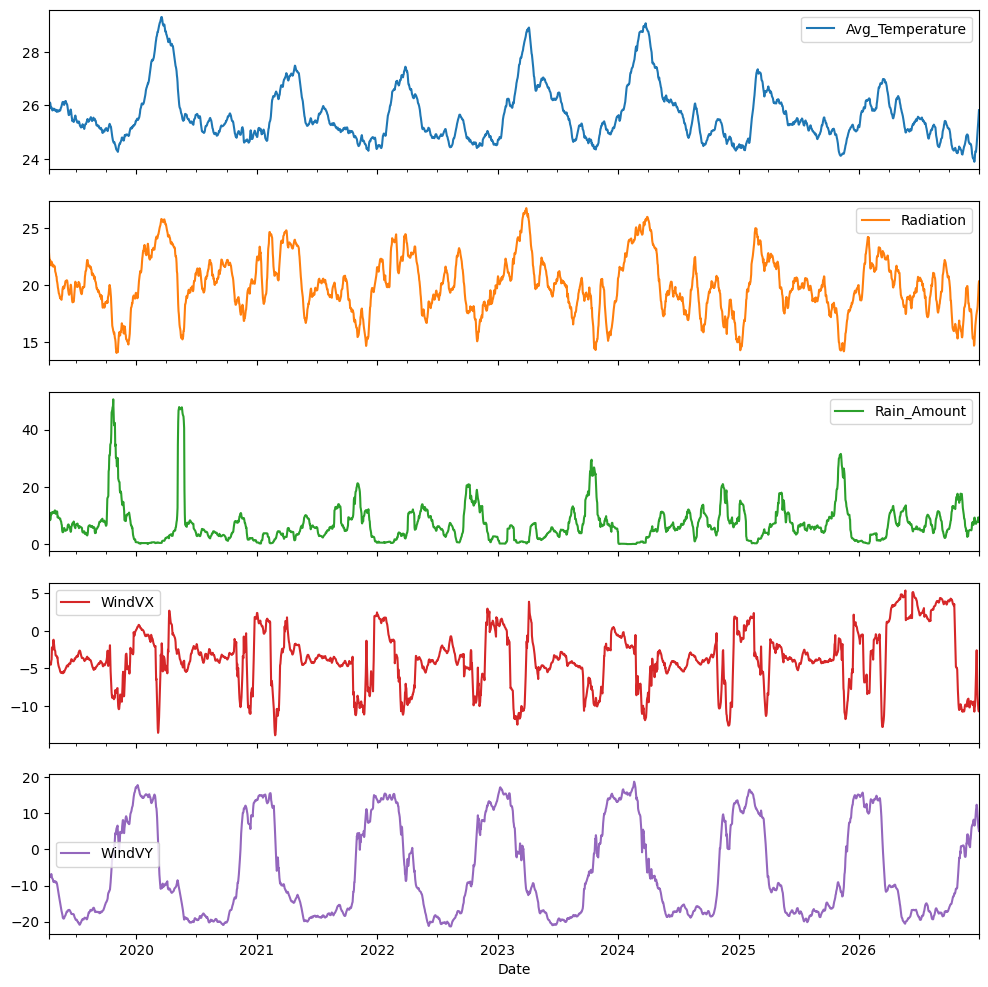

In [9]:
df[df['kingdom']=='Arcadia'][targets].plot(subplots=True, figsize=(12, 12))

In [1]:
df[targets]

NameError: name 'df' is not defined

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

def smape(y_true, y_pred):
    epsilon = tf.keras.backend.epsilon()  # Small value to avoid division by zero
    numerator = tf.abs(y_true - y_pred)
    denominator = (tf.abs(y_true) + tf.abs(y_pred) + epsilon) / 2
    return tf.reduce_mean(numerator / denominator) * 100  # Convert to percentage

X = df[features]
Y = df[targets]

X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.2, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test) 

model = Sequential([
    Input((len(features),)), 
    Dense(64, activation='relu'), 
    Dense(64, activation='relu'), 
    Dense(64, activation='relu'), 
    Dense(len(targets))
])

model.compile(optimizer='adam', loss='mse', metrics=[smape])

model.fit(X_train_scaled, Y_train, validation_data=(X_val_scaled, Y_val), epochs=4)


test_loss = model.evaluate(X_test_scaled, Y_test)
print("Test Loss:", test_loss)

Epoch 1/4
2124/2124 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 51.3883 - smape: 61.6391 - val_loss: 13.0402 - val_smape: 37.9401
Epoch 2/4
2124/2124 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 11.7855 - smape: 36.8685 - val_loss: 9.7469 - val_smape: 35.1348
Epoch 3/4
2124/2124 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 8.8902 - smape: 33.8055 - val_loss: 7.8313 - val_smape: 31.9428
Epoch 4/4
2124/2124 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 7.2615 - smape: 31.3129 - val_loss: 6.6021 - val_smape: 30.5980
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.5236 - smape: 30.4958
Test Loss: [6.649812698364258, 30.467941284179688]


In [16]:
kingdoms

{'Arcadia': {'latitude': 24.2800015, 'longitude': -37.22998},
 'Atlantis': {'latitude': 22.9799985, 'longitude': -37.32999},
 'Avalon': {'latitude': 22.88, 'longitude': -37.130006},
 'Camelot': {'latitude': 24.180003, 'longitude': -36.92999400000001},
 'Dorne': {'latitude': 25.780002, 'longitude': -37.53},
 'Eden': {'latitude': 23.7800015, 'longitude': -37.630006},
 'El Dorado': {'latitude': 23.680003, 'longitude': -37.22998},
 'Elysium': {'latitude': 23.7800015, 'longitude': -37.630006},
 'Emerald City': {'latitude': 23.4799985, 'longitude': -37.53},
 'Helios': {'latitude': 24.38, 'longitude': -37.130006},
 'Krypton': {'latitude': 23.7800015, 'longitude': -37.630006},
 'Metropolis': {'latitude': 23.88, 'longitude': -37.630006},
 'Midgar': {'latitude': 24.88, 'longitude': -37.72998},
 'Midgard': {'latitude': 24.4799985, 'longitude': -36.92999400000001},
 'Mordor': {'latitude': 23.0800046, 'longitude': -36.32999},
 'Neo-City': {'latitude': 23.680003, 'longitude': -37.630006},
 'Neo-Toky

In [24]:
df[features]

,latitude,longitude,sin_day_of_354,cos_day_of_354,sin_day_of_188,cos_day_of_188,sin_day_of_177,cos_day_of_177
Date,,,,,,,,
2019-04-11,24.280002,-37.229980,0.194002,0.981001,3.594078e-01,0.933181,0.380633,0.924726
2019-04-12,24.280002,-37.229980,0.211383,0.977403,3.903893e-01,0.920650,0.413212,0.910635
2019-04-13,24.280002,-37.229980,0.228696,0.973498,4.209348e-01,0.907091,0.445271,0.895396
2019-04-14,24.280002,-37.229980,0.245938,0.969285,4.510101e-01,0.892519,0.476769,0.879029
2019-04-15,24.280002,-37.229980,0.263103,0.964768,4.805818e-01,0.876950,0.507666,0.861554
...,...,...,...,...,...,...,...,...
2026-12-18,23.979999,-36.429994,-0.228696,0.973498,-3.341498e-02,0.999442,-0.445271,0.895396
2026-12-19,23.979999,-36.429994,-0.211383,0.977403,6.432491e-16,1.000000,-0.413212,0.910635
2026-12-20,23.979999,-36.429994,-0.194002,0.981001,3.341498e-02,0.999442,-0.380633,0.924726


In [29]:
df[targets]

,Avg_Temperature,Radiation,Rain_Amount,WindVX,WindVY
Date,,,,,
2019-04-11,26.120,22.8650,11.5245,-4.077005,-7.798591
2019-04-12,26.060,22.4265,9.4055,-4.363431,-7.618981
2019-04-13,26.095,22.2530,8.5865,-4.357559,-7.639614
2019-04-14,26.110,22.1590,8.3590,-4.467652,-7.691626
2019-04-15,26.085,22.1590,8.4760,-4.463437,-7.653583
...,...,...,...,...,...
2026-12-18,21.425,15.7990,17.1340,-4.985785,6.604360
2026-12-19,21.545,16.1620,17.1925,-4.102435,6.978471
2026-12-20,21.595,16.5015,17.1665,-3.202113,7.673702


In [38]:
test = pd.read_csv('/kaggle/input/data-crunch-round-1/test.csv')
ids = test['ID'].to_numpy()
test['latitude'] = test['kingdom'].apply(lambda k:kingdoms[k]['latitude'])
test['longitude'] = test['kingdom'].apply(lambda k:kingdoms[k]['longitude'])
test['Date'] = test.apply(lambda row: to_date(row['Year'], row['Month'], row['Day']), axis=1)
test.set_index('Date', inplace=True)
test = add_period(test)
test_x = test[features]
test_x_scaled = scaler.transform(test_x)
preds = model.predict(test_x_scaled)
preds_df = pd.DataFrame(preds, index=ids, columns=targets)
preds_df = preds_df.reset_index().rename(columns={'index': 'ID'})
preds_df['Wind_Speed'] = np.sqrt(preds_df['WindVX']**2 + preds_df['WindVY']**2)
preds_df['Wind_Direction'] = np.degrees(np.arctan2(preds_df['WindVY'], preds_df['WindVX'])) % 360
preds_df.drop(columns=['WindVX', 'WindVY'], inplace=True)
preds_df

142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,ID,Avg_Temperature,Radiation,Rain_Amount,Wind_Speed,Wind_Direction
0,84961,25.060347,20.928892,7.745368,9.219477,176.047760
1,84962,26.909866,22.385338,11.952401,9.594334,188.072052
2,84963,27.500822,22.862892,11.137597,10.171401,193.186707
3,84964,23.563923,20.584970,9.638774,8.311941,156.508347
4,84965,27.532423,21.465164,4.747723,15.049159,164.886795
...,...,...,...,...,...,...
4525,89486,29.713020,24.365088,1.630313,25.804302,274.387756
4526,89487,28.442690,23.486423,1.904317,31.867336,259.457306
4527,89488,26.093870,19.291393,8.759367,17.997696,262.201721
4528,89489,28.530317,23.544020,2.349533,14.920513,228.342026


In [39]:
preds_df.to_csv('/kaggle/working/my_data2.csv')

In [52]:
pred = model.predict(X_train_scaled)

2124/2124 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [10]:
df[features]

,latitude,longitude,sin_day_of_354,cos_day_of_354,sin_day_of_188,cos_day_of_188,sin_day_of_177,cos_day_of_177
Date,,,,,,,,
2019-04-11,24.280002,-37.229980,0.194002,0.981001,3.594078e-01,0.933181,0.380633,0.924726
2019-04-12,24.280002,-37.229980,0.211383,0.977403,3.903893e-01,0.920650,0.413212,0.910635
2019-04-13,24.280002,-37.229980,0.228696,0.973498,4.209348e-01,0.907091,0.445271,0.895396
2019-04-14,24.280002,-37.229980,0.245938,0.969285,4.510101e-01,0.892519,0.476769,0.879029
2019-04-15,24.280002,-37.229980,0.263103,0.964768,4.805818e-01,0.876950,0.507666,0.861554
...,...,...,...,...,...,...,...,...
2026-12-18,23.979999,-36.429994,-0.228696,0.973498,-3.341498e-02,0.999442,-0.445271,0.895396
2026-12-19,23.979999,-36.429994,-0.211383,0.977403,6.432491e-16,1.000000,-0.413212,0.910635
2026-12-20,23.979999,-36.429994,-0.194002,0.981001,3.341498e-02,0.999442,-0.380633,0.924726


In [53]:
len(X_train_scaled)

67966

In [66]:
pred.T[0]

array([29.178339, 24.890165, 28.85209 , ..., 29.12441 , 25.992441,
       25.933424], dtype=float32)

In [63]:
Y_train.to_numpy().T[0]

array([30.5, 22.9, 29.8, ..., 29.7, 25.6, 25.5])

In [85]:
df['longitude'][0:1]

Date
2019-04-03   -37.22998
Name: longitude, dtype: float64

In [88]:
df[(df['latitude']==24.2800)]

,latitude,longitude,sin_day_of_354,cos_day_of_354,sin_day_of_188,cos_day_of_188,sin_day_of_177,cos_day_of_177,Avg_Temperature_lag_1,Radiation_lag_1,...,Avg_Temperature_lag_2,Radiation_lag_2,Rain_Amount_lag_2,WindVX_lag_2,WindVY_lag_2,Avg_Temperature,Radiation,Rain_Amount,WindVX,WindVY
Date,,,,,,,,,,,,,,,,,,,,,


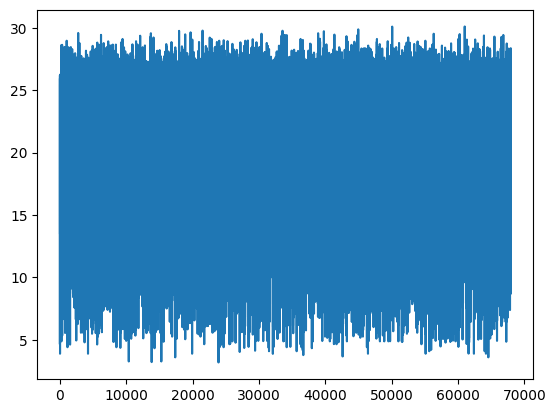

In [76]:
nad = np.arange(len(X_train_scaled))
plt.plot(nad, Y_train.to_numpy().T[1])

In [35]:
p = model.predict(X_train_scaled)

2124/2124 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
